<a href="https://colab.research.google.com/github/DataInfamous/pediatric-cancer-research-gaps/blob/main/pediatric_research_gap_analysis.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
!pip install scipy matplotlib seaborn pandas numpy -q


In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
from scipy import stats
import warnings
warnings.filterwarnings('ignore')

print('Libraries loaded.')


Libraries loaded.


In [ ]:
from google.colab import files
uploaded = files.upload() # Please upload 'stalled_trials_clean.csv' here
df = pd.read_csv('stalled_trials_clean.csv')

categories = {
    'ALL':          ['acute lymphoblastic leukemia', ' all ', 'lymphoblastic'],
    'AML':          ['acute myeloid leukemia', 'aml', 'myeloid leukemia', 'myelogenous'],
    'Hodgkin':      ['hodgkin'],
    'NHL':          ['non-hodgkin', 'burkitt', 'nhl', "non hodgkin"],
    'CNS':          ['brain tumor', 'brain cancer', 'glioma', 'medulloblastoma',
                     'ependymoma', 'astrocytoma', 'cns tumor', 'central nervous system',
                     'glioblastoma', 'pnet', 'craniopharyngioma'],
    'Neuroblastoma':['neuroblastoma'],
    'Wilms':        ['wilms', 'nephroblastoma'],
    'Osteosarcoma': ['osteosarcoma'],
    'Ewing':        ["ewing"],
    'STS':          ['rhabdomyosarcoma', 'soft tissue sarcoma', 'synovial sarcoma',
                     'fibrosarcoma'],
}

def categorize(title):
    t = title.lower()
    for cat, keywords in categories.items():
        for kw in keywords:
            if kw.lower() in t:
                return cat
    if 'lymphoma' in t:
        return 'NHL'
    if 'leukemia' in t or 'leukemias' in t:
        return 'ALL'
    if 'sarcoma' in t:
        return 'STS'
    return 'Other/Mixed'

df['disease_category'] = df['BriefTitle'].apply(categorize)
counts = df['disease_category'].value_counts()
print('Stalled trials by disease category:')
print(counts)
print(f"\nCategorized: {(df['disease_category'] != 'Other/Mixed').sum()} / {len(df)}")

Saving stalled_trials_clean.csv to stalled_trials_clean (2).csv
Stalled trials by disease category:
disease_category
Other/Mixed      665
ALL               89
CNS               86
Neuroblastoma     29
AML               26
STS               14
NHL               13
Osteosarcoma       9
Hodgkin            9
Ewing              7
Wilms              3
Name: count, dtype: int64

Categorized: 285 / 950


In [ ]:
# CDC WONDER: Age-adjusted incidence per million, 1999-2022
incidence = {
    'ALL':           33.8,
    'AML':            8.1,
    'Hodgkin':       12.2,
    'NHL':           11.9,
    'CNS':           31.3,
    'Neuroblastoma':  8.5,
    'Wilms':          6.2,
    'Osteosarcoma':   5.1,
    'Ewing':          3.0,
    'STS':           12.0,
}

# CCSS: Non-recurrence mortality burden
# Subsequent malignancy % + Cardiac % + Pulmonary % of all cases
# Source: CCSS Jan 2020 freeze, NDI through 12/31/2017
non_recurrence = {
    'ALL':           28.0,   # 20.5 + 5.1 + 2.4
    'AML':           35.8,   # 19.5 + 11.4 + 4.9
    'Hodgkin':       58.4,   # 32.2 + 20.5 + 5.7
    'NHL':           43.5,   # 24.7 + 13.3 + 5.5
    'CNS':           21.8,   # 15.3 + 2.9 + 3.6
    'Neuroblastoma': 26.4,   # 18.9 + 3.2 + 4.3
    'Wilms':         32.0,   # 24.2 + 5.6 + 2.2
    'Osteosarcoma':  40.1,   # 28.1 + 7.4 + 4.6
    'Ewing':         30.8,   # 19.8 + 9.9 + 1.1
    'STS':           34.0,   # 27.2 + 5.2 + 1.6
}

stalled_counts = df[df['disease_category'] != 'Other/Mixed']['disease_category'].value_counts().to_dict()

diseases = list(incidence.keys())
analysis_df = pd.DataFrame({
    'disease':                  diseases,
    'incidence_rate':           [incidence[d] for d in diseases],
    'non_recurrence_mortality': [non_recurrence[d] for d in diseases],
    'stalled_trials':           [stalled_counts.get(d, 0) for d in diseases],
})

analysis_df['trials_per_incidence'] = (
    analysis_df['stalled_trials'] / analysis_df['incidence_rate']
)
analysis_df['late_effects_burden_index'] = (
    analysis_df['non_recurrence_mortality'] / analysis_df['incidence_rate']
)

analysis_df = analysis_df.sort_values('late_effects_burden_index', ascending=False)
print(analysis_df.to_string(index=False))


      disease  incidence_rate  non_recurrence_mortality  stalled_trials  trials_per_incidence  late_effects_burden_index
        Ewing             3.0                      30.8               7              2.333333                  10.266667
 Osteosarcoma             5.1                      40.1               9              1.764706                   7.862745
        Wilms             6.2                      32.0               3              0.483871                   5.161290
      Hodgkin            12.2                      58.4               9              0.737705                   4.786885
          AML             8.1                      35.8              26              3.209877                   4.419753
          NHL            11.9                      43.5              13              1.092437                   3.655462
Neuroblastoma             8.5                      26.4              29              3.411765                   3.105882
          STS            12.0   

In [ ]:
r1, p1 = stats.spearmanr(analysis_df['incidence_rate'], analysis_df['stalled_trials'])
r2, p2 = stats.spearmanr(analysis_df['non_recurrence_mortality'], analysis_df['stalled_trials'])
r3, p3 = stats.spearmanr(analysis_df['late_effects_burden_index'], analysis_df['stalled_trials'])

print('=== SPEARMAN CORRELATIONS WITH STALLED TRIAL COUNT ===')
print(f'Incidence rate:              rho = {r1:+.3f}, p = {p1:.3f} {"*" if p1 < 0.05 else ""}')
print(f'Non-recurrence mortality:    rho = {r2:+.3f}, p = {p2:.3f} {"*" if p2 < 0.05 else ""}')
print(f'Late-effects burden index:   rho = {r3:+.3f}, p = {p3:.3f} {"*" if p3 < 0.05 else ""}')
print()
print('* p < 0.05')
print()
print('INTERPRETATION:')
print(f'  Research activity tracks incidence (rho={r1:+.3f}, p={p1:.3f})')
print(f'  Research activity is NEGATIVELY correlated with late-effects burden (rho={r3:+.3f}, p={p3:.3f})')
print()
print('  Finding: The more disproportionate the late-effects burden relative to incidence,')
print('  the FEWER stalled trials exist — suggesting research investment is not aligned')
print('  with survivor harm.')


=== SPEARMAN CORRELATIONS WITH STALLED TRIAL COUNT ===
Incidence rate:              rho = +0.711, p = 0.021 *
Non-recurrence mortality:    rho = -0.505, p = 0.137 
Late-effects burden index:   rho = -0.881, p = 0.001 *

* p < 0.05

INTERPRETATION:
  Research activity tracks incidence (rho=+0.711, p=0.021)
  Research activity is NEGATIVELY correlated with late-effects burden (rho=-0.881, p=0.001)

  Finding: The more disproportionate the late-effects burden relative to incidence,
  the FEWER stalled trials exist — suggesting research investment is not aligned
  with survivor harm.


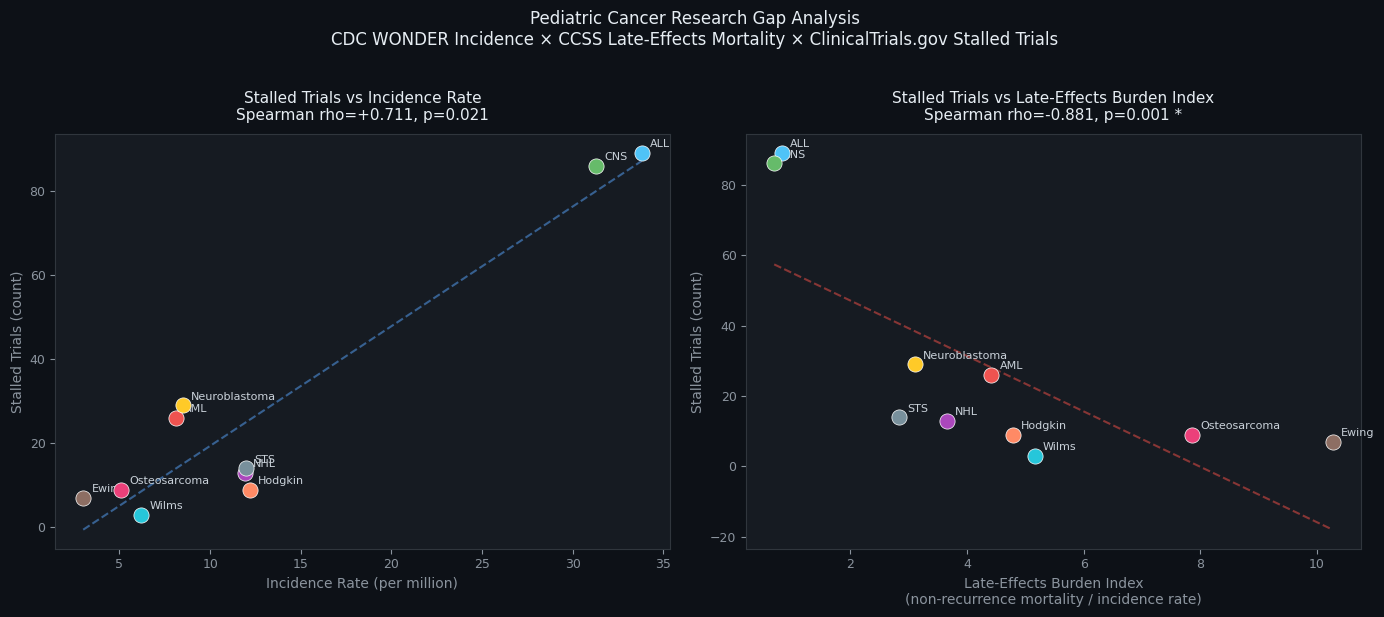

In [ ]:
colors = {
    'ALL': '#4fc3f7', 'AML': '#ef5350', 'Hodgkin': '#ff8a65',
    'NHL': '#ab47bc', 'CNS': '#66bb6a', 'Neuroblastoma': '#ffca28',
    'Wilms': '#26c6da', 'Osteosarcoma': '#ec407a',
    'Ewing': '#8d6e63', 'STS': '#78909c'
}

fig, axes = plt.subplots(1, 2, figsize=(14, 6))
fig.patch.set_facecolor('#0d1117')

for ax in axes:
    ax.set_facecolor('#161b22')
    ax.tick_params(colors='#8b949e', labelsize=9)
    ax.spines[:].set_color('#30363d')

ax1 = axes[0]
for _, row in analysis_df.iterrows():
    ax1.scatter(row['incidence_rate'], row['stalled_trials'],
                color=colors[row['disease']], s=120, zorder=5,
                edgecolors='white', linewidth=0.5)
    ax1.annotate(row['disease'],
                 (row['incidence_rate'], row['stalled_trials']),
                 textcoords='offset points', xytext=(6, 4),
                 fontsize=8, color='#c9d1d9')

x = analysis_df['incidence_rate'].values
y = analysis_df['stalled_trials'].values
z = np.polyfit(x, y, 1)
p_line = np.poly1d(z)
x_line = np.linspace(x.min(), x.max(), 100)
ax1.plot(x_line, p_line(x_line), '--', color='#58a6ff', alpha=0.5, linewidth=1.5)
ax1.set_xlabel('Incidence Rate (per million)', color='#8b949e', fontsize=10)
ax1.set_ylabel('Stalled Trials (count)', color='#8b949e', fontsize=10)
ax1.set_title(f'Stalled Trials vs Incidence Rate\nSpearman rho={r1:+.3f}, p={p1:.3f}',
              color='#e6edf3', fontsize=11, pad=10)

ax2 = axes[1]
for _, row in analysis_df.iterrows():
    ax2.scatter(row['late_effects_burden_index'], row['stalled_trials'],
                color=colors[row['disease']], s=120, zorder=5,
                edgecolors='white', linewidth=0.5)
    ax2.annotate(row['disease'],
                 (row['late_effects_burden_index'], row['stalled_trials']),
                 textcoords='offset points', xytext=(6, 4),
                 fontsize=8, color='#c9d1d9')

x2 = analysis_df['late_effects_burden_index'].values
z2 = np.polyfit(x2, y, 1)
p2_line = np.poly1d(z2)
x2_line = np.linspace(x2.min(), x2.max(), 100)
ax2.plot(x2_line, p2_line(x2_line), '--', color='#f85149', alpha=0.5, linewidth=1.5)
ax2.set_xlabel('Late-Effects Burden Index\n(non-recurrence mortality / incidence rate)',
               color='#8b949e', fontsize=10)
ax2.set_ylabel('Stalled Trials (count)', color='#8b949e', fontsize=10)
ax2.set_title(f'Stalled Trials vs Late-Effects Burden Index\nSpearman rho={r3:+.3f}, p={p3:.3f} *',
              color='#e6edf3', fontsize=11, pad=10)

fig.suptitle(
    'Pediatric Cancer Research Gap Analysis\n'
    'CDC WONDER Incidence × CCSS Late-Effects Mortality × ClinicalTrials.gov Stalled Trials',
    color='#e6edf3', fontsize=12, y=1.02
)
plt.tight_layout()
plt.savefig('scatter_plots.png', dpi=150, bbox_inches='tight',
            facecolor='#0d1117', edgecolor='none')
plt.show()


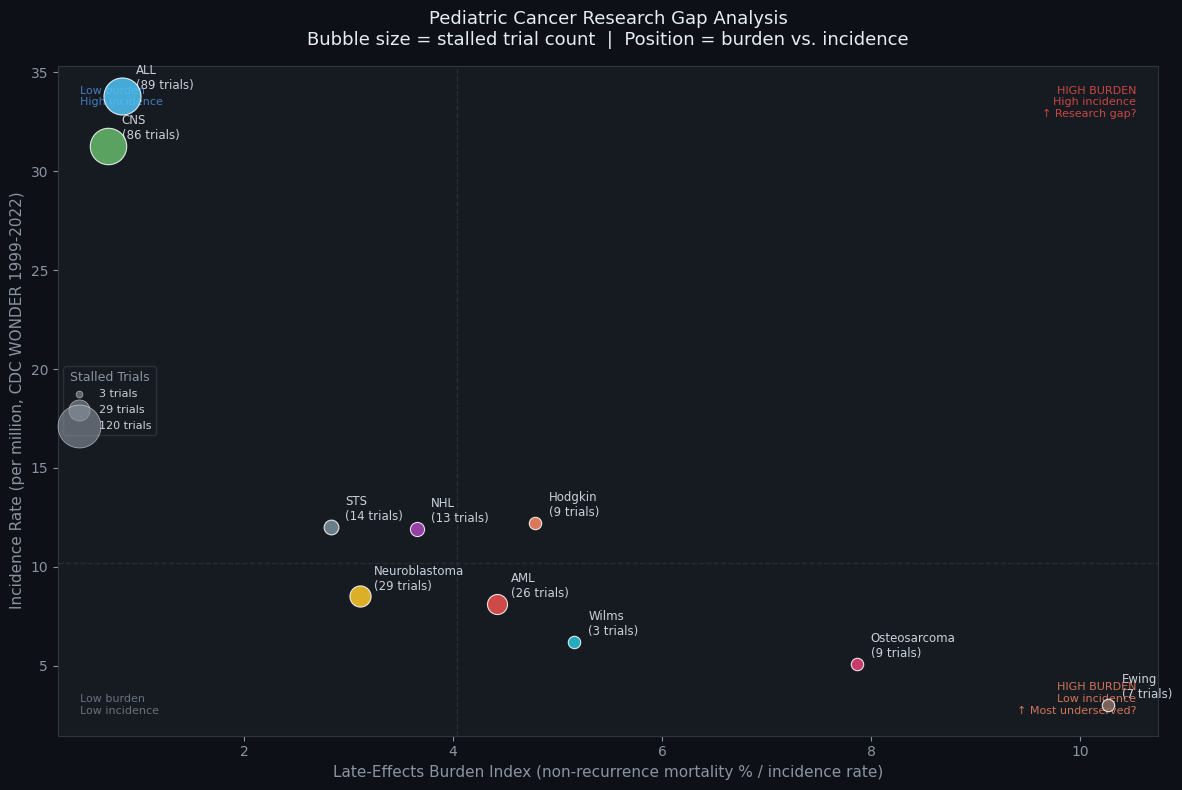

In [ ]:
fig, ax = plt.subplots(figsize=(12, 8))
fig.patch.set_facecolor('#0d1117')
ax.set_facecolor('#161b22')
ax.tick_params(colors='#8b949e', labelsize=10)
ax.spines[:].set_color('#30363d')

for _, row in analysis_df.iterrows():
    size = max(row['stalled_trials'] * 8, 80)
    ax.scatter(row['late_effects_burden_index'], row['incidence_rate'],
               s=size, color=colors[row['disease']], alpha=0.85,
               edgecolors='white', linewidth=0.8, zorder=5)
    ax.annotate(f"{row['disease']}\n({int(row['stalled_trials'])} trials)",
                (row['late_effects_burden_index'], row['incidence_rate']),
                textcoords='offset points', xytext=(10, 5),
                fontsize=8.5, color='#c9d1d9')

x_med = analysis_df['late_effects_burden_index'].median()
y_med = analysis_df['incidence_rate'].median()
ax.axvline(x_med, color='#30363d', linestyle='--', linewidth=1, alpha=0.7)
ax.axhline(y_med, color='#30363d', linestyle='--', linewidth=1, alpha=0.7)

ax.text(0.02, 0.97, 'Low burden\nHigh incidence',
        transform=ax.transAxes, fontsize=8, color='#58a6ff', alpha=0.7, va='top', ha='left')
ax.text(0.98, 0.97, 'HIGH BURDEN\nHigh incidence\n↑ Research gap?',
        transform=ax.transAxes, fontsize=8, color='#f85149', alpha=0.8, va='top', ha='right')
ax.text(0.02, 0.03, 'Low burden\nLow incidence',
        transform=ax.transAxes, fontsize=8, color='#8b949e', alpha=0.7, va='bottom', ha='left')
ax.text(0.98, 0.03, 'HIGH BURDEN\nLow incidence\n↑ Most underserved?',
        transform=ax.transAxes, fontsize=8, color='#ff8a65', alpha=0.8, va='bottom', ha='right')

ax.set_xlabel('Late-Effects Burden Index (non-recurrence mortality % / incidence rate)',
              color='#8b949e', fontsize=11)
ax.set_ylabel('Incidence Rate (per million, CDC WONDER 1999-2022)',
              color='#8b949e', fontsize=11)
ax.set_title('Pediatric Cancer Research Gap Analysis\n'
             'Bubble size = stalled trial count  |  Position = burden vs. incidence',
             color='#e6edf3', fontsize=13, pad=15)

for n, label in [(3, '3 trials'), (29, '29 trials'), (120, '120 trials')]:
    ax.scatter([], [], s=n*8, color='#8b949e', alpha=0.6,
               label=label, edgecolors='white', linewidth=0.5)
legend = ax.legend(title='Stalled Trials', title_fontsize=9,
                   labelcolor='#c9d1d9', fontsize=8,
                   facecolor='#161b22', edgecolor='#30363d', loc='center left')
legend.get_title().set_color('#8b949e')

plt.tight_layout()
plt.savefig('bubble_chart.png', dpi=150, bbox_inches='tight',
            facecolor='#0d1117', edgecolor='none')
plt.show()


In [ ]:
analysis_df.to_csv('pediatric_research_gap_results.csv', index=False)
print('Saved: pediatric_research_gap_results.csv')
print('Saved: scatter_plots.png')
print('Saved: bubble_chart.png')


Saved: pediatric_research_gap_results.csv
Saved: scatter_plots.png
Saved: bubble_chart.png
